In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving price_data (1).csv to price_data (1).csv
Saving client_data (1).csv to client_data (1).csv


In [5]:
df_client = pd.read_csv('client_data (1).csv')
df_price = pd.read_csv('price_data (1).csv')



In [6]:

print("Missing values in df_client:")
display(df_client.isnull().sum())

Missing values in df_client:


,0
id,0
channel_sales,0
cons_12m,0
cons_gas_12m,0
cons_last_month,0
date_activ,0
date_end,0
date_modif_prod,0
date_renewal,0
forecast_cons_12m,0


In [7]:
print("Missing values in df_price:")
display(df_price.isnull().sum())

Missing values in df_price:


,0
id,0
price_date,0
price_off_peak_var,0
price_peak_var,0
price_mid_peak_var,0
price_off_peak_fix,0
price_peak_fix,0
price_mid_peak_fix,0


In [8]:
print("\nData types and non-null values for df_client:")
df_client.info()


Data types and non-null values for df_client:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null

In [9]:
print("\nData types and non-null values for df_price:")
df_price.info()


Data types and non-null values for df_price:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [10]:

date_cols_client = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols_client:
    df_client[col] = pd.to_datetime(df_client[col], errors='coerce')


df_price['price_date'] = pd.to_datetime(df_price['price_date'], errors='coerce')

print("Date columns converted to datetime. Displaying updated info for df_client:")
df_client.info()
print("\nDisplaying updated info for df_price:")
df_price.info()

Date columns converted to datetime. Displaying updated info for df_client:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       


# Descriptive Statistics


In [11]:
display(df_price.describe())

,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,2015-06-16 12:50:49.933161216,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 00:00:00,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,2015-07-01 00:00:00,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,2015-10-01 00:00:00,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,2015-12-01 00:00:00,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221
std,NaN,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592


In [12]:
display(df_client.describe())

,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,...,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912448,2016-07-27 20:48:26.422018560,2013-01-02 12:29:10.951663872,2015-07-21 06:59:00.353279488,1868.614880,1399.762906,0.966726,...,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,...,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,...,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,...,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,...,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,...,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175


# Churn Distribution


Churn Distribution:
churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64


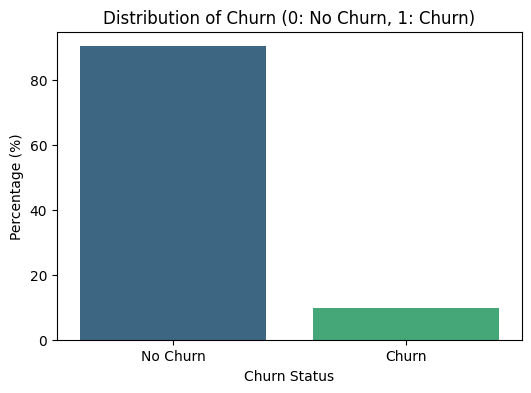

In [13]:
churn_distribution = df_client['churn'].value_counts(normalize=True) * 100
print("Churn Distribution:")
print(churn_distribution)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_distribution.index, y=churn_distribution.values, hue=churn_distribution.index, palette='viridis', legend=False)
plt.title('Distribution of Churn (0: No Churn, 1: Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

### Distribution of Key Numerical Features by Churn Status


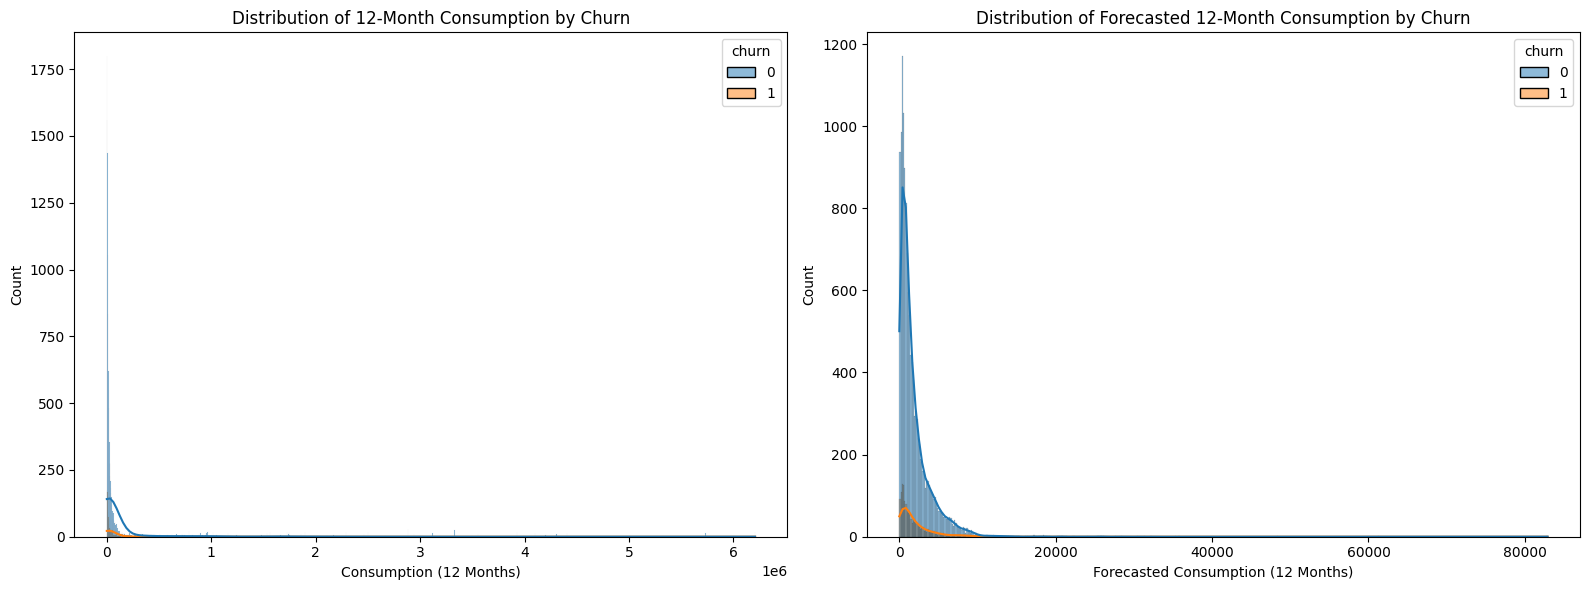

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of 'cons_12m' by churn status
sns.histplot(data=df_client, x='cons_12m', hue='churn', kde=True, ax=axes[0])
axes[0].set_title('Distribution of 12-Month Consumption by Churn')
axes[0].set_xlabel('Consumption (12 Months)')
axes[0].set_ylabel('Count')

# Distribution of 'forecast_cons_12m' by churn status
sns.histplot(data=df_client, x='forecast_cons_12m', hue='churn', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Forecasted 12-Month Consumption by Churn')
axes[1].set_xlabel('Forecasted Consumption (12 Months)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Next, let's look at client seniority and net margin to see their distributions relative to churn.

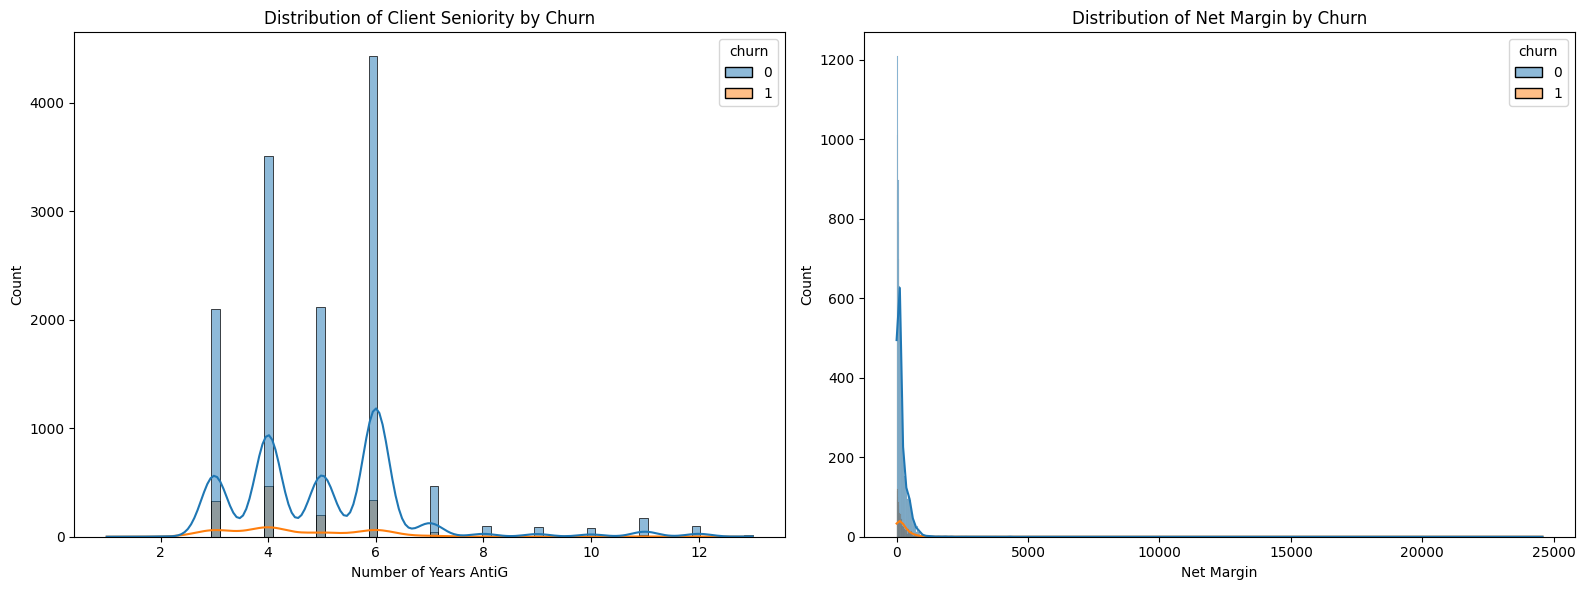

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of 'num_years_antig' by churn status
sns.histplot(data=df_client, x='num_years_antig', hue='churn', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Client Seniority by Churn')
axes[0].set_xlabel('Number of Years AntiG')
axes[0].set_ylabel('Count')

# Distribution of 'net_margin' by churn status
sns.histplot(data=df_client, x='net_margin', hue='churn', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Net Margin by Churn')
axes[1].set_xlabel('Net Margin')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Distribution of Categorical Features by Churn Status

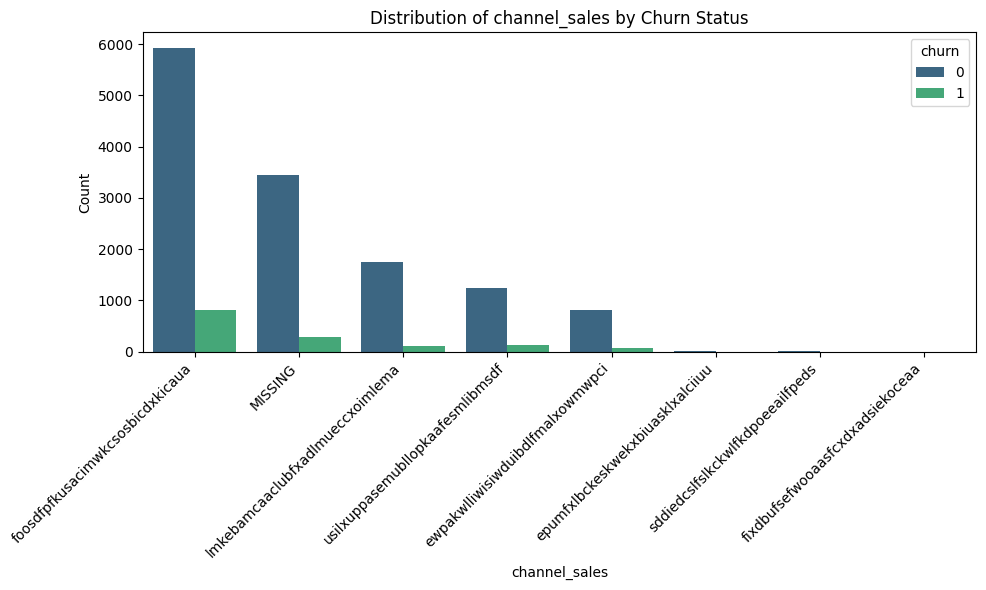

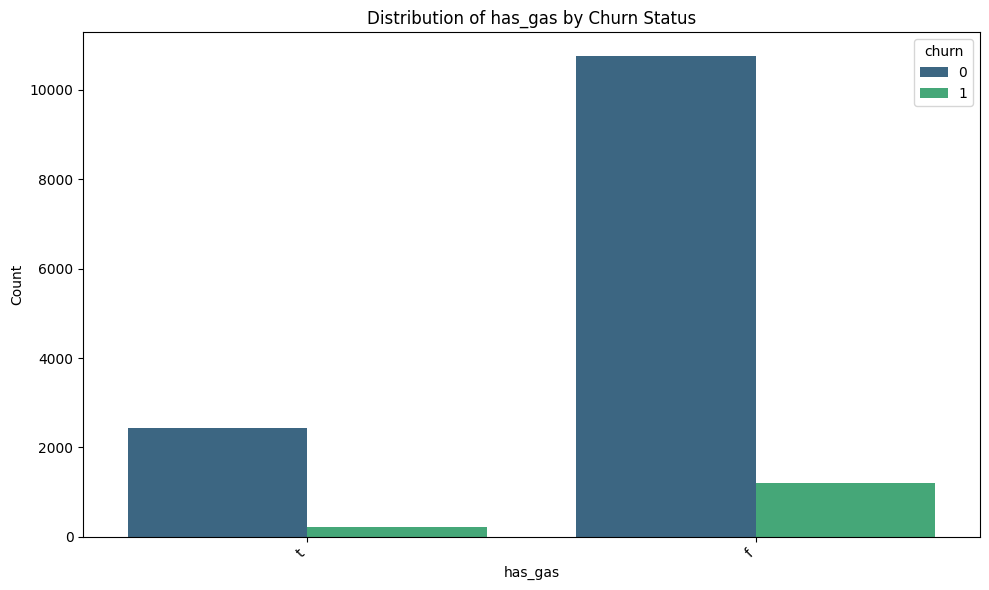

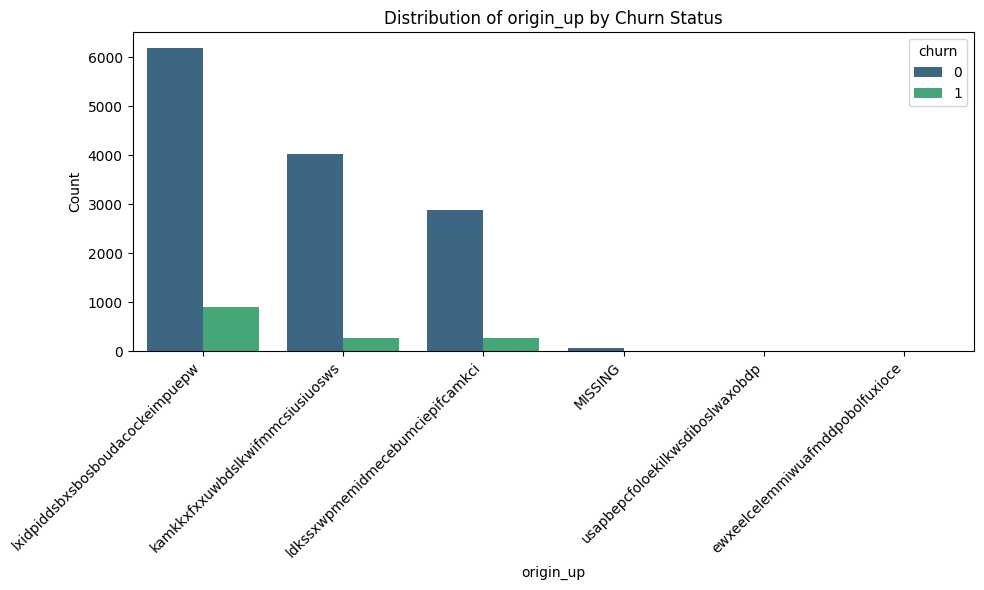

In [28]:
categorical_cols = ['channel_sales', 'has_gas', 'origin_up']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_client, x=col, hue='churn', palette='viridis')
    plt.title(f'Distribution of {col} by Churn Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Preparing Data for Logistic Regression

To perform logistic regression, we need to convert categorical features into a numerical format using one-hot encoding. We'll also separate the features (X) from our target variable (y), which is `churn`.

In [15]:
# Drop the 'id' column as it's just an identifier and not a feature
df_model = df_client.drop('id', axis=1)

# Identify categorical and numerical columns
categorical_cols = df_model.select_dtypes(include='object').columns
numerical_cols = df_model.select_dtypes(include=['int64', 'float64']).columns
date_cols = df_model.select_dtypes(include=['datetime64[ns]']).columns

# Exclude 'churn' from numerical columns as it's our target
numerical_features = [col for col in numerical_cols if col != 'churn']

# Handle date columns: for simplicity in this initial model, we'll drop them.
# In a real scenario, features could be extracted from dates (e.g., tenure, time since last activity).
df_model = df_model.drop(columns=date_cols)

# Perform one-hot encoding for categorical features
df_model_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Separate features (X) and target (y)
X = df_model_encoded.drop('churn', axis=1)
y = df_model_encoded['churn']

print("Shape of X after encoding:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:")
display(X.head())
print("First 5 rows of y:")
display(y.head())

Shape of X after encoding: (14606, 30)
Shape of y: (14606,)
First 5 rows of X:


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,has_gas_t,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp
0,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,...,True,False,False,False,True,False,False,False,True,False
1,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,...,False,False,False,False,False,False,True,False,False,False
2,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,...,True,False,False,False,False,False,True,False,False,False
3,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,...,False,True,False,False,False,False,True,False,False,False
4,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,...,False,False,False,False,False,False,True,False,False,False


First 5 rows of y:


,churn
0,1
1,0
2,0
3,0
4,0


### Training Logistic Regression Model

Now, we'll split the data into training and testing sets, and then train a Logistic Regression model. We will also scale the numerical features to ensure they contribute equally to the model.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features (important for Logistic Regression and many other models)
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with column names for interpretability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Initialize and train the Logistic Regression model
# We'll set max_iter to a higher value to ensure convergence
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model.fit(X_train_scaled_df, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Evaluating Model Performance and Identifying Key Predictors

Finally, we'll evaluate the model's performance using various metrics and examine the coefficients to understand which features are most indicative of churn.

In [17]:
# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled_df)
y_pred_proba = model.predict_proba(X_test_scaled_df)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

print("\n--- Key Predictors (Feature Coefficients) ---")
# Create a DataFrame of feature coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute coefficient value to see the most influential features
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

display(coefficients.head(10))

Accuracy: 0.9021
Precision: 0.2500
Recall: 0.0035
F1-Score: 0.0069
ROC AUC: 0.6370
Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,2635,3
Actual Churn,283,1



--- Key Predictors (Feature Coefficients) ---


,Feature,Coefficient,Abs_Coefficient
7,forecast_price_energy_off_peak,-0.282394,0.282394
28,origin_up_lxidpiddsbxsbosboudacockeimpuepw,0.268072,0.268072
9,forecast_price_pow_off_peak,0.250016,0.250016
1,cons_gas_12m,-0.234199,0.234199
14,net_margin,0.226858,0.226858
15,num_years_antig,-0.199496,0.199496
16,pow_max,-0.186214,0.186214
12,margin_net_pow_ele,0.172796,0.172796
21,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,-0.149217,0.149217
22,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,-0.148228,0.148228
